In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt

plt.style.use('default')  # resets to light theme


In [2]:
import xarray as xr
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import BaggingRegressor
from catboost import CatBoostRegressor

from highres_ta.evaluation import scoring, make_prediction_df,  build_groupers
from highres_ta.preprocessing import compute_n_coords, load_config, load_data, preprocess_data, get_train_test_data

# Load train, test data

In [3]:
config = load_config("./training_iterations_config.yaml")
print(config)

Munch({'fname_data_parquet': 'data/training/GLODAPv2023-raw_collocated-{y}.pq', 'yname_target': 'talk', 'xname_features': ['salinity', 'temperature', 'bottomdepth', 'mld_dens_soda', 'ssh_adt', 'ssh_sla', 'chl_globcolour', 'ncoord_a', 'ncoord_b', 'ncoord_c'], 'outliers_filter': Munch({'lower_sal': 25, 'upper_sal': 40, 'lower_depth': 150}), 'ith_split': 0, 'bagged_estimator_params': Munch({'n_estimators': 20, 'polynomial_degree': 1, 'max_samples': 0.2, 'loss_function': 'MAE', 'linear_features': ['salinity'], 'n_jobs': 8})})


In [4]:
df_raw = load_data()

df = preprocess_data(df_raw, config)

train_x, train_y, test_x, test_y = get_train_test_data(df, config)


2026-04-23 23:43:25.328 | INFO     | highres_ta.preprocessing:load_data:61 - Loading data from /home/edupuis/highres_TA/data/training/GLODAPv2023-raw_collocated-YYYY.pq for years 1982-2021


2026-04-23 23:43:26.239 | INFO     | highres_ta.preprocessing:filter_outliers:126 - Filter outliers (25 < salinity < 40) & (150 < bottomdepth)
2026-04-23 23:43:26.416 | INFO     | highres_ta.preprocessing:get_train_test_data:222 - Selecting the 0^th split iteration
2026-04-23 23:43:26.422 | SUCCESS  | highres_ta.preprocessing:get_train_test_data:234 - X_features ['salinity', 'temperature', 'bottomdepth', 'mld_dens_soda', 'ssh_adt', 'ssh_sla', 'chl_globcolour', 'ncoord_a', 'ncoord_b', 'ncoord_c'] enforced in train_x, test_x
2026-04-23 23:43:26.424 | SUCCESS  | highres_ta.preprocessing:get_train_test_data:235 - Target variable talk enforced in train_y, test_y


In [5]:
train_x

salinity  \
expocode     time                lat     lon       salinity_bin             
18SN19970924 1997-09-25 02:31:00 70.4530 -141.6900 1              31.0050   
             1997-09-25 18:24:00 70.7930 -141.8300 1              30.5540   
             1997-09-25 21:45:00 71.0300 -141.9900 1              27.0090   
             1997-09-26 01:39:00 71.2560 -142.0200 1              29.0130   
316N19971005 1997-10-19 00:00:00 50.3620 -33.3520  3              34.9740   
...                                                                   ...   
49UP20210728 2021-08-11 17:20:00 24.2462  142.4377 3              34.4862   
             2021-08-12 13:00:00 24.2667  143.6297 3              34.3840   
                                                   3              34.3784   
             2021-08-13 05:58:00 24.2552  144.8202 3              34.5543   
                                                   3              34.5550   

                                                                 temperature  \
expocode     time                lat     lon       salinity_bin                
18SN19970924 1997-09-25 02:31:00 70.4530 -141.6900 1                 -0.4837   
             1997-09-25 18:24:00 70.7930 -141.8300 1                 -0.0138   
             1997-09-25 21:45:00 71.0300 -141.9900 1                  2.2540   
             1997-09-26 01:39:00 71.2560 -142.0200 1                  0.1928   
316N19971005 1997-10-19 00:00:00 50.3620 -33.3520  3                 14.3040   
...                                                                      ...   
49UP20210728 2021-08-11 17:20:00 24.2462  142.4377 3                 28.1655   
             2021-08-12 13:00:00 24.2667  143.6297 3                 28.9275   
                                                   3                 28.9258   
             2021-08-13 05:58:00 24.2552  144.8202 3                 28.8603   
                                                   3                 28.8512   

                                                                 bottomdepth  \
expocode     time                lat     lon       salinity_bin                
18SN19970924 1997-09-25 02:31:00 70.4530 -141.6900 1                   247.0   
             1997-09-25 18:24:00 70.7930 -141.8300 1                  1856.7   
             1997-09-25 21:45:00 71.0300 -141.9900 1                  2410.0   
             1997-09-26 01:39:00 71.2560 -142.0200 1                  2885.9   
316N19971005 1997-10-19 00:00:00 50.3620 -33.3520  3                  4165.5   
...                                                                      ...   
49UP20210728 2021-08-11 17:20:00 24.2462  142.4377 3                  2928.0   
             2021-08-12 13:00:00 24.2667  143.6297 3                  8364.0   
                                                   3                  8364.0   
             2021-08-13 05:58:00 24.2552  144.8202 3                  5415.8   
                                                   3                  5415.8   

                                                                 mld_dens_soda  \
expocode     time                lat     lon       salinity_bin                  
18SN19970924 1997-09-25 02:31:00 70.4530 -141.6900 1                  7.225576   
             1997-09-25 18:24:00 70.7930 -141.8300 1                  6.479418   
             1997-09-25 21:45:00 71.0300 -141.9900 1                  5.325035   
             1997-09-26 01:39:00 71.2560 -142.0200 1                  6.627090   
316N19971005 1997-10-19 00:00:00 50.3620 -33.3520  3                 27.397478   
...                                                                        ...   
49UP20210728 2021-08-11 17:20:00 24.2462  142.4377 3                 12.954788   
             2021-08-12 13:00:00 24.2667  143.6297 3                 13.161998   
                                                   3                 13.161998   
             2021-08-13 05:58:00 24.2552  144.8202 3                 16.488873 

In [6]:
train_y

expocode      time                 lat      lon        salinity_bin
18SN19970924  1997-09-25 02:31:00  70.4530  -141.6900  1               2222.3
              1997-09-25 18:24:00  70.7930  -141.8300  1               2190.9
              1997-09-25 21:45:00  71.0300  -141.9900  1               2092.1
              1997-09-26 01:39:00  71.2560  -142.0200  1               2133.4
316N19971005  1997-10-19 00:00:00  50.3620  -33.3520   3               2310.3
                                                                        ...  
49UP20210728  2021-08-11 17:20:00  24.2462   142.4377  3               2266.1
              2021-08-12 13:00:00  24.2667   143.6297  3               2255.8
                                                       3               2256.1
              2021-08-13 05:58:00  24.2552   144.8202  3               2268.8
                                                       3               2269.1
Name: talk, Length: 19927, dtype: float64

# Fit models

In [7]:
import highres_ta.estimators as models

In [8]:
print(config.bagged_estimator_params)


# bagged_model = models.BaggingCatBoostResidualRegressor(
#     n_estimators=20, 
#     polynomial_degree=1,
#     max_samples=0.2,
#     loss_function="MAE",
#     linear_features=config.linear_features,
#     n_jobs=8,
# )

bagged_model = models.BaggingCatBoostResidualRegressor(**config.bagged_estimator_params)


Munch({'n_estimators': 20, 'polynomial_degree': 1, 'max_samples': 0.2, 'loss_function': 'MAE', 'linear_features': ['salinity'], 'n_jobs': 8})


In [9]:
bagged_model.fit(train_x, train_y)
train_yhat = bagged_model.predict(train_x)
train_predictions_df = make_prediction_df(y_pred = train_yhat, y_true=train_y) 
train_scores = scoring(train_predictions_df)

2026-04-23 23:43:45.338 | INFO     | highres_ta.evaluation:scoring:28 - |                         |           0 |
|:------------------------|------------:|
| root_mean_squared_error | 17.8655     |
| mean_absolute_error     |  7.62836    |
| huber_loss              |  9.45691    |
| median_absolute_error   |  3.51192    |
| mean_bias               |  0.706519   |
| median_bias             | -0.00902776 |
| r2_score                |  0.962162   |


In [10]:
# train_predictions_df = make_prediction_df(y_pred = train_yhat, y_true=train_y) 
# train_predictions_df
# train_scores = scoring(train_predictions_df)

In [11]:
# grouper = build_groupers(train_predictions_df, time_freq='year',salinity_group=True)
# train_predictions_df_grouped = train_predictions_df.groupby(grouper)
# train_predictions_df_grouped

In [12]:
# time_index = train_predictions_df.index.get_level_values('time')
# yearly_train_scores = grouped_scoring(train_predictions_df)
# yearly_train_scores




In [13]:
print(bagged_model.feature_names_in_)

['salinity' 'temperature' 'bottomdepth' 'mld_dens_soda' 'ssh_adt'
 'ssh_sla' 'chl_globcolour' 'ncoord_a' 'ncoord_b' 'ncoord_c']


# Test scores

In [14]:
# the prediction flow:
# 1) get the baseline prediction from the linear model
# 2) get the residual prediction from the bagged booster
# 3) sum them to get the final prediction
test_yhat = bagged_model.predict(test_x)
test_predictions_df = make_prediction_df(test_yhat, test_y)
test_scores = scoring(test_predictions_df)

2026-04-23 23:43:46.474 | INFO     | highres_ta.evaluation:scoring:28 - |                         |         0 |
|:------------------------|----------:|
| root_mean_squared_error | 16.5122   |
| mean_absolute_error     |  8.58603  |
| huber_loss              | 10.7322   |
| median_absolute_error   |  4.62407  |
| mean_bias               |  1.02547  |
| median_bias             |  0.201669 |
| r2_score                |  0.96886  |


# Load inference data (single timestep)

In [15]:
url = "https://data.up.ethz.ch/shared/OceanSODA-ETHZv2/.inference_for_gregor2024/data_8daily_25km_v01.zarr/"
ds = xr.open_zarr(url, consolidated=True, group='2004')

ds["bottomdepth"] = xr.open_dataarray("../data/bathymetry_etopo2022_25km.nc")
rename = dict(
    sss="salinity",
    sst="temperature",
    ssh="ssh_adt",
    ssh_anom="ssh_sla",
    mld="mld_dens_soda",
    chl_filled="chl_globcolour",
    bottomdepth="bottomdepth",
)
ds = ds.rename(rename)[list(rename.values())]
ds = ds.isel(time=33, drop=True)
df = ds.to_dataframe()
coords = df.index.to_frame()
df['ncoord_a'], df['ncoord_b'], df['ncoord_c'] = compute_n_coords(coords['lat'], coords['lon'])
df['depth'] = 0

coords = df.index.to_frame()
n_coords = compute_n_coords(coords["lat"], coords["lon"])
df = df.join(n_coords)
pred_X = df.dropna()[train_x.columns]

In [16]:
df

salinity  temperature  ssh_adt  ssh_sla  mld_dens_soda  \
lat     lon                                                                 
-89.875 -179.875        NaN          NaN      NaN      NaN            NaN   
        -179.625        NaN          NaN      NaN      NaN            NaN   
        -179.375        NaN          NaN      NaN      NaN            NaN   
        -179.125        NaN          NaN      NaN      NaN            NaN   
        -178.875        NaN          NaN      NaN      NaN            NaN   
...                     ...          ...      ...      ...            ...   
 89.875  178.875  31.327675    -1.799994      NaN      NaN            NaN   
         179.125  31.335012    -1.799994      NaN      NaN            NaN   
         179.375  31.335012    -1.799994      NaN      NaN            NaN   
         179.625        NaN    -1.799994      NaN      NaN            NaN   
         179.875        NaN    -1.799994      NaN      NaN            NaN   

                  chl_globcolour  bottomdepth  ncoord_a  ncoord_b  ncoord_c  \
lat     lon                                                                   
-89.875 -179.875             NaN            0 -0.002182 -0.000005 -0.999998   
        -179.625             NaN            0 -0.002182 -0.000014 -0.999998   
        -179.375             NaN            0 -0.002182 -0.000024 -0.999998   
        -179.125             NaN            0 -0.002181 -0.000033 -0.999998   
        -178.875             NaN            0 -0.002181 -0.000043 -0.999998   
...                          ...          ...       ...       ...       ...   
 89.875  178.875             NaN            0 -0.002181  0.000043  0.999998   
         179.125             NaN            0 -0.002181  0.000033  0.999998   
         179.375             NaN            0 -0.002182  0.000024  0.999998   
         179.625             NaN            0 -0.002182  0.000014  0.999998   
         179.875             NaN            0 -0.002182  0.000005  0.999998   

                  depth         0         1       lat  
lat     lon                                            
-89.875 -179.875      0 -0.002182 -0.000005 -0.999998  
        -179.625      0 -0.002182 -0.000014 -0.999998  
        -179.375      0 -0.002182 -0.000024 -0.999998  
        -179.125      0 -0.002181 -0.000033 -0.999998  
        -178.875      0 -0.002181 -0.000043 -0.999998  
...                 ...       ...       ...       ...  
 89.875  178.875      0 -0.002181  0.000043  0.999998  
         179.125      0 -0.002181  0.000033  0.999998  
         179.375      0 -0.002182  0.000024  0.999998  
         179.625      0 -0.002182  0.000014  0.999998  
         179.875      0 -0.002182  0.000005  0.999998  

[1036800 rows x 14 columns]

# Create mapped estimates

In [17]:
import numpy as np
full_results = np.vstack((bagged_model.predict(pred_X, return_std=True),
bagged_model.predict_linear(pred_X, return_std=True),
bagged_model.predict_catboost(pred_X, return_std=True),))

In [18]:
pred_y = pd.DataFrame(
    data=full_results.T,
    columns=["mean_prediction", "std_prediction", "mean_linear", "std_linear", "mean_catboost", "std_catboost"],
    index=pred_X.index,
).to_xarray().astype("float32").chunk()
pred_y["std_combined"] = ((pred_y.std_catboost**2 + pred_y.std_linear**2)**0.5).chunk()

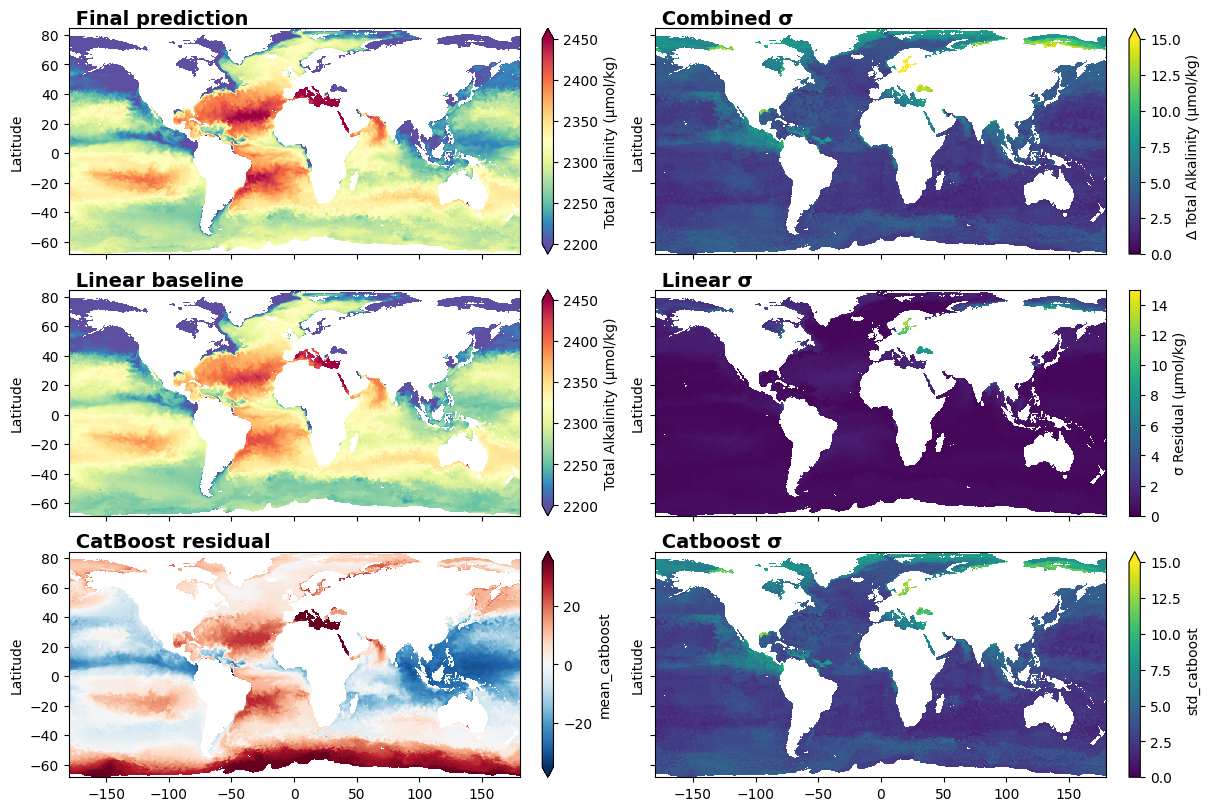

In [19]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 2, figsize=(12, 8), squeeze=False, sharex=True, sharey=True, constrained_layout=True)
img1 = pred_y.mean_prediction.plot.imshow(vmin=2200, vmax=2450, ax=axs[0, 0], cmap="Spectral_r")
img2 = pred_y.std_combined.plot.imshow(vmin=0, vmax=15, ax=axs[0, 1])
img3 = pred_y.mean_linear.plot.imshow(vmin=2200, vmax=2450, ax=axs[1, 0], cmap="Spectral_r")
img4 = pred_y.std_linear.plot.imshow(vmin=0, vmax=15, ax=axs[1, 1])
img5 = pred_y.mean_catboost.plot.imshow(robust=True, ax=axs[2, 0])
img6 = pred_y.std_catboost.plot.imshow(vmin=0, vmax=15, ax=axs[2, 1])

[ax.set_ylabel('') for ax in axs.flat]
[ax.set_xlabel('') for ax in axs.flat]

# img3.get_clim()
# img1.set_clim(img3.get_clim())

img1.colorbar.set_label("Total Alkalinity (µmol/kg)")
img2.colorbar.set_label("∆ Total Alkalinity (µmol/kg)")
img3.colorbar.set_label("Total Alkalinity (µmol/kg)")
img4.colorbar.set_label("σ Residual (µmol/kg)")

text_props = dict(fontsize=14, fontweight='bold', color='black', loc='left', va='top')
axs = axs.flatten()
axs[0].set_title(" Final prediction", **text_props)
axs[1].set_title(" Combined σ", **text_props)
axs[2].set_title(" Linear baseline", **text_props)
axs[3].set_title(" Linear σ", **text_props)
axs[4].set_title(" CatBoost residual", **text_props)
axs[5].set_title(" Catboost σ", **text_props)

for ax in axs.flatten():
    ax.set_xlabel("")
    ax.set_ylabel("Latitude")
    

<Axes: >

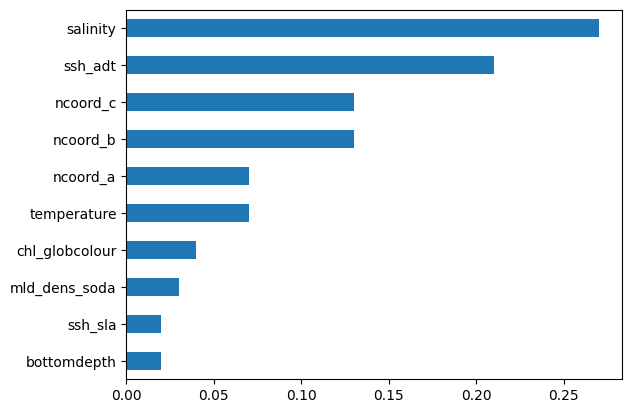

In [20]:
pd.Series(bagged_model.estimators_[0].boosting_model_.get_feature_importance(), index=train_x.columns).pipe(lambda s: s / s.sum()).sort_values(ascending=True).round(2).plot.barh()